# Counterfactual Explanations — XGBoost MS Subtype Classification

## 1. Introduction

### What are Counterfactual Explanations?

Counterfactual explanations answer "what-if" questions:

> *"What would need to change about this patient for the model to predict a different subtype?"*

For example: *"If this SPMS patient had 3 fewer years of disease duration and their EDSS was 2.0 lower, the model would classify them as RRMS."*

### Why Counterfactuals?

| Aspect | SHAP | Counterfactual |
|--------|------|----------------|
| Question | *Why this prediction?* | *What would change the prediction?* |
| Output | Feature contributions | Actionable changes |
| Use case | Understanding | Action planning |

### DiCE (Diverse Counterfactual Explanations)

We use Microsoft's **DiCE** framework, which generates **multiple diverse** counterfactuals rather than just one. This shows doctors various scenarios that could lead to a different classification.

### Clinical Relevance

- **Treatment planning:** What changes would "upgrade" a patient from SPMS features to a better outcome?
- **Disease monitoring:** Which features are closest to a subtype boundary?
- **Patient communication:** Explain in concrete terms what distinguishes subtypes
- **Research insight:** Reveal the decision boundaries of the classifier

---

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import dice_ml

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, f1_score, classification_report
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 13,
    'figure.figsize': (10, 6), 'axes.grid': True, 'grid.alpha': 0.3,
})

COLORS = {'RRMS': '#2196F3', 'SPMS': '#FF5722', 'PPMS': '#4CAF50'}

print(f"DiCE version: {"DiCE"}")
print("Setup complete.")

DiCE version: DiCE
Setup complete.


## 3. Data Preparation and Model Training

We use the same preprocessing and XGBoost model as the baseline and SHAP notebooks.

In [2]:
# Load data
df = pd.read_csv('../datasets/ms_dataset.csv')
feature_cols = [c for c in df.columns if c != 'subtype']
X = df[feature_cols]
y = df['subtype']

le = LabelEncoder()
y_encoded = le.fit_transform(y)
class_names = le.classes_

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=RANDOM_STATE, stratify=y_encoded
)

# Impute
imputer = SimpleImputer(strategy='median')
X_train_ready = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_ready = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

sample_weights = compute_sample_weight('balanced', y_train)

print(f"Train: {X_train_ready.shape}, Test: {X_test_ready.shape}")
print(f"Classes: {list(class_names)}")

Train: (420, 16), Test: (105, 16)
Classes: ['PPMS', 'RRMS', 'SPMS']


In [3]:
# Train XGBoost
model = XGBClassifier(
    objective='multi:softprob', n_estimators=300,
    learning_rate=0.1, max_depth=5, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE, n_jobs=-1
)
model.fit(X_train_ready, y_train, sample_weight=sample_weights, verbose=False)

y_pred = model.predict(X_test_ready)
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")

Test Accuracy: 0.8952
Test Macro F1: 0.8698


## 4. Setting Up DiCE

DiCE needs three things:
1. **Data description** — what kind of features we have (continuous vs categorical)
2. **Model wrapper** — how to get predictions from our model
3. **Counterfactual generator** — the algorithm to find counterfactuals

In [4]:
# Prepare data for DiCE
# DiCE with sklearn backend works best with integer-encoded labels
train_for_dice = X_train_ready.copy()
train_for_dice['subtype'] = y_train  # integer-encoded labels

# Define feature types
continuous_features = [c for c in feature_cols if c not in ['sex_encoded', 'treatment_status']]

# Build class index mapping for reference
class_index_map = {name: idx for idx, name in enumerate(class_names)}
print(f"Continuous features ({len(continuous_features)}): {continuous_features}")
print(f"Outcome: subtype (integer-encoded)")
print(f"Class mapping: {class_index_map}")

Continuous features (14): ['age', 'age_at_onset', 'edss', 'disease_duration', 'relapse_count', 'brain_volume', 'gm_volume', 'wm_volume', 'lesion_count', 'lesion_volume', 'edss_progression_rate', 'gm_ratio', 'wm_ratio', 'lesion_burden_ratio']
Outcome: subtype (integer-encoded)
Class mapping: {'PPMS': 0, 'RRMS': 1, 'SPMS': 2}


In [5]:
# Create DiCE data object
dice_data = dice_ml.Data(
    dataframe=train_for_dice,
    continuous_features=continuous_features,
    outcome_name='subtype'
)
print("DiCE Data object created.")

DiCE Data object created.


In [6]:
# Use XGBoost model directly (no wrapper needed for integer labels)
dice_model = dice_ml.Model(model=model, backend='sklearn')
print("DiCE Model object created.")

DiCE Model object created.


In [7]:
# Create the counterfactual explainer
dice_exp = dice_ml.Dice(dice_data, dice_model, method='random')
print("DiCE explainer ready (method=random)")

DiCE explainer ready (method=random)


## 5. Generating Counterfactual Explanations

### How it Works

For each patient, DiCE finds the **smallest changes** to features that would flip the model's prediction to a different subtype. It generates **multiple diverse** counterfactuals so we can see different "paths" to a different classification.

### What to Look For

- **Which features change?** → These are the features closest to a decision boundary
- **How much do they change?** → Small changes = the patient is near a boundary
- **Which features stay the same?** → These are not relevant for this classification boundary

In [8]:
# Generate counterfactuals for one patient per subtype
y_pred_test = model.predict(X_test_ready)
results = {}

# For multi-class with integer labels, specify target as integer class index
# Strategy: for each subtype, flip to the most clinically relevant alternative
target_map = {}  # source_class_idx -> target_class_idx
for idx_src, name_src in enumerate(class_names):
    if name_src == 'PPMS':
        target_map[idx_src] = list(class_names).index('RRMS')  # PPMS -> RRMS
    elif name_src == 'RRMS':
        target_map[idx_src] = list(class_names).index('SPMS')  # RRMS -> SPMS
    elif name_src == 'SPMS':
        target_map[idx_src] = list(class_names).index('RRMS')  # SPMS -> RRMS

for class_idx, name in enumerate(class_names):
    # Find a correctly classified patient
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() > 0:
        idx = np.where(mask)[0][0]
        patient = X_test_ready.iloc[[idx]]
        pred_label = class_names[y_pred_test[idx]]
        target_idx = target_map[class_idx]
        target_name = class_names[target_idx]
        
        print(f"\n{'='*60}")
        print(f"Patient (test index {idx}): Predicted as {pred_label}")
        print(f"Target counterfactual class: {target_name} (index {target_idx})")
        print(f"{'='*60}")
        print(f"Current feature values:")
        for col in feature_cols:
            print(f"  {col:30s} {patient[col].values[0]:.2f}")
        
        # Generate 3 diverse counterfactuals using integer target class
        try:
            cf = dice_exp.generate_counterfactuals(
                patient,
                total_CFs=3,
                desired_class=int(target_idx),
                features_to_vary=continuous_features,
                random_seed=RANDOM_STATE
            )
            results[name] = {'idx': idx, 'patient': patient, 'cf': cf, 'target': target_name}
            cf.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f"  Could not generate CFs: {e}")
            results[name] = None


Patient (test index 0): Predicted as PPMS
Target counterfactual class: RRMS (index 1)
Current feature values:
  age                            55.00
  sex_encoded                    1.00
  age_at_onset                   44.00
  edss                           3.50
  disease_duration               11.00
  relapse_count                  0.00
  treatment_status               1.00
  brain_volume                   1303211.50
  gm_volume                      583393.80
  wm_volume                      369355.80
  lesion_count                   3.00
  lesion_volume                  17658.50
  edss_progression_rate          0.60
  gm_ratio                       0.45
  wm_ratio                       0.28
  lesion_burden_ratio            0.01



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  5.04it/s]


100%|██████████| 1/1 [00:00<00:00,  5.01it/s]

Query instance (original outcome : 0)


...


100%|██████████| 1/1 [00:00<00:00,  4.59it/s]

Query instance (original outcome : 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,46.400002,0.0,29.0,6.0,17.4,0.0,0.0,1588441.0,589662.0,434781.0,5.0,32723.0,0.344828,0.371221,0.273716,0.020601,2



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,2.2,9.1,-,-,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,1.3,-,-,-,-,-,-,-,-,1.55240246,0.3793,-,-,1.0
2,-,-,-,0.3,1.2,-,-,-,-,-,-,-,0.34388521,-,-,-,1.0


## 6. Targeted Counterfactual Explanations

Instead of just flipping to any class, let's ask specific clinical questions:

- **SPMS patient → RRMS:** What would need to change to move from secondary progressive to relapsing-remitting?
- **PPMS patient → RRMS:** What differentiates primary progressive from relapsing-remitting?


In [9]:
# Targeted: For each non-RRMS patient, generate CFs that flip to RRMS
targeted_results = {}
rrms_idx = int(list(class_names).index('RRMS'))

for source_subtype in ['SPMS', 'PPMS']:
    class_idx = list(class_names).index(source_subtype) if source_subtype in class_names else None
    if class_idx is None:
        continue
    
    mask = (y_test == class_idx) & (y_pred_test == class_idx)
    if mask.sum() == 0:
        continue
    
    idx = np.where(mask)[0][0]
    patient = X_test_ready.iloc[[idx]]
    
    print(f"\n{'='*60}")
    print(f"{source_subtype} Patient -> What would make them RRMS?")
    print(f"{'='*60}")
    print(f"Current values:")
    for col in feature_cols:
        print(f"  {col:30s} {patient[col].values[0]:.2f}")
    
    try:
        cf = dice_exp.generate_counterfactuals(
            patient,
            total_CFs=3,
            desired_class=rrms_idx,
            features_to_vary=continuous_features,
            random_seed=RANDOM_STATE
        )
        targeted_results[source_subtype] = {'idx': idx, 'patient': patient, 'cf': cf}
        cf.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"  Could not generate targeted CFs: {e}")


SPMS Patient -> What would make them RRMS?
Current values:
  age                            46.40
  sex_encoded                    0.00
  age_at_onset                   29.00
  edss                           6.00
  disease_duration               17.40
  relapse_count                  0.00
  treatment_status               0.00
  brain_volume                   1588441.00
  gm_volume                      589662.00
  wm_volume                      434781.00
  lesion_count                   5.00
  lesion_volume                  32723.00
  edss_progression_rate          0.34
  gm_ratio                       0.37
  wm_ratio                       0.27
  lesion_burden_ratio            0.02



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:00<00:00,  5.24it/s]


100%|██████████| 1/1 [00:00<00:00,  5.21it/s]

Query instance (original outcome : 2)


...


100%|██████████| 1/1 [00:00<00:00,  5.57it/s]

Query instance (original outcome : 0)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,55.0,1.0,44.0,3.5,11.0,0.0,1.0,1303211.5,583393.8125,369355.8125,3.0,17658.5,0.6016,0.4477,0.2834,0.01355,0



Diverse Counterfactual set (new outcome: 1)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,-,-,1.5,-,-,-,-,-,-,-,-,-,-,1.0
1,24.9,-,-,1.5,-,-,-,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,2.0,-,-,-,-,-,-,-,-,-,-,1.0


## 7. Analyzing Counterfactual Patterns

### Which Features Change Most?

By looking across all counterfactuals, we can see which features most commonly need to change for a subtype reclassification. These are the features at the **decision boundary**.

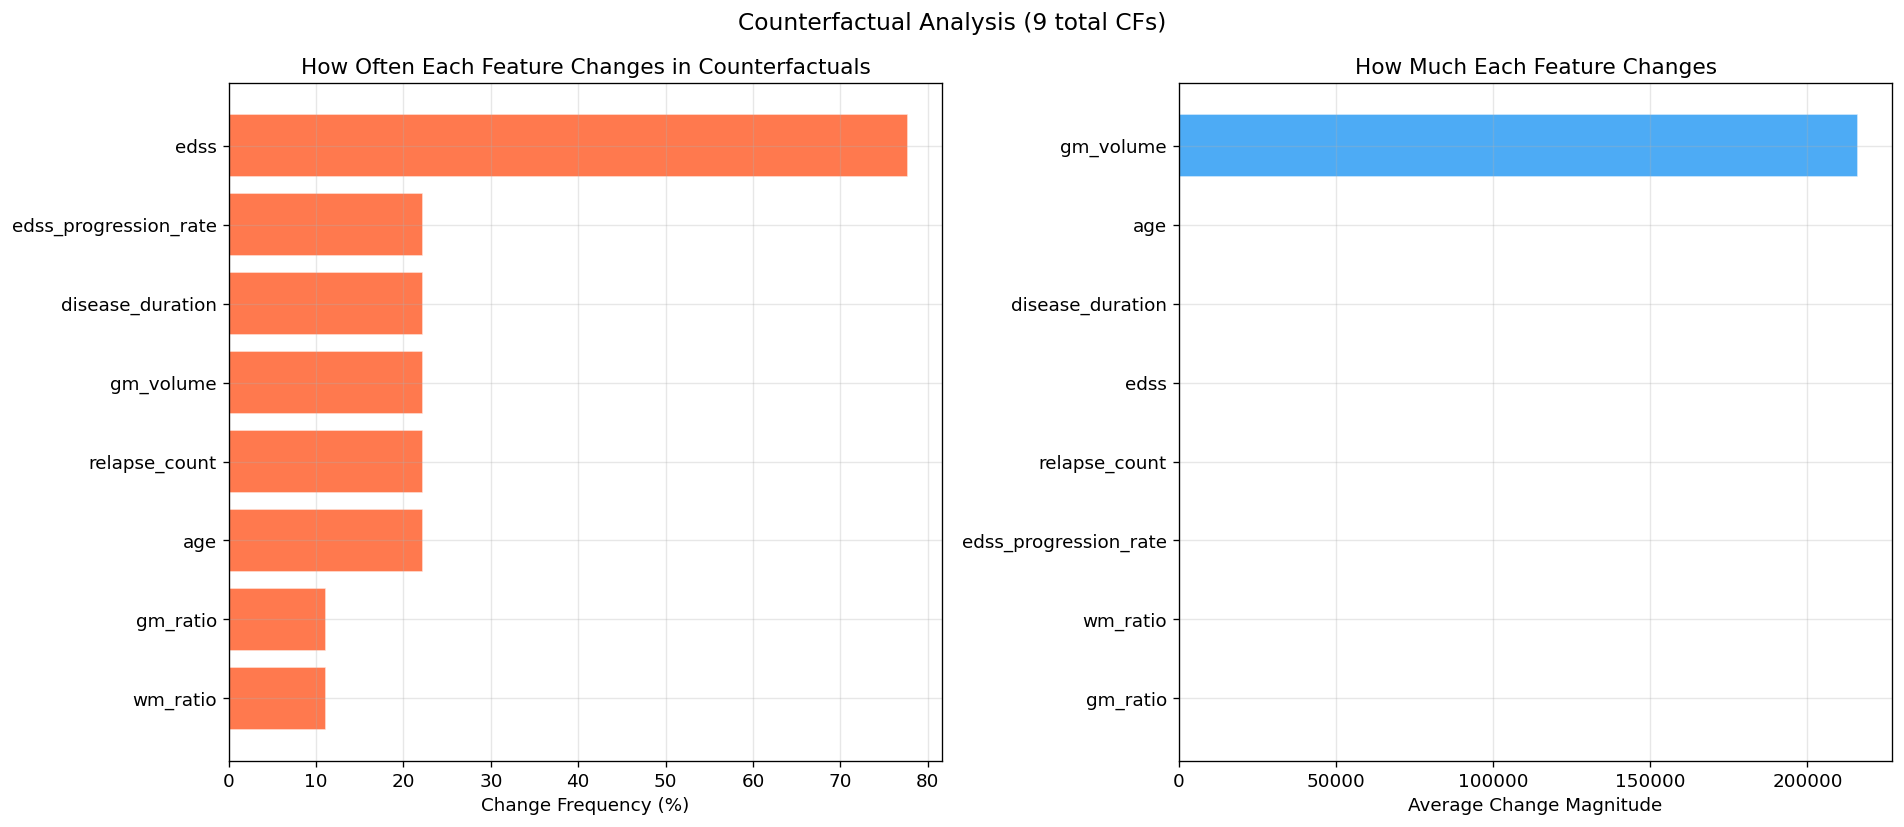

In [10]:
# Analyze feature changes across all counterfactuals
feature_change_counts = {f: 0 for f in feature_cols}
feature_change_magnitudes = {f: [] for f in feature_cols}
total_cfs = 0

for name, data in results.items():
    if data is None or data['cf'] is None:
        continue
    try:
        cf_df = data['cf'].cf_examples_list[0].final_cfs_df
        original = data['patient']
        
        for _, cf_row in cf_df.iterrows():
            total_cfs += 1
            for feat in feature_cols:
                if feat in cf_row and feat in original.columns:
                    orig_val = original[feat].values[0]
                    cf_val = cf_row[feat]
                    if isinstance(cf_val, (int, float)) and abs(cf_val - orig_val) > 1e-6:
                        feature_change_counts[feat] += 1
                        feature_change_magnitudes[feat].append(abs(cf_val - orig_val))
    except Exception:
        pass

if total_cfs > 0:
    # Plot feature change frequency
    change_df = pd.DataFrame({
        'Feature': feature_cols,
        'Change Frequency': [feature_change_counts[f] / total_cfs * 100 for f in feature_cols],
        'Avg Magnitude': [np.mean(feature_change_magnitudes[f]) if feature_change_magnitudes[f] else 0 for f in feature_cols]
    }).sort_values('Change Frequency', ascending=True)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Frequency
    change_df_nonzero = change_df[change_df['Change Frequency'] > 0]
    axes[0].barh(change_df_nonzero['Feature'], change_df_nonzero['Change Frequency'],
                 color='#FF5722', alpha=0.8, edgecolor='white')
    axes[0].set_xlabel('Change Frequency (%)')
    axes[0].set_title('How Often Each Feature Changes in Counterfactuals')
    
    # Magnitude
    mag_df = change_df[change_df['Avg Magnitude'] > 0].sort_values('Avg Magnitude', ascending=True)
    axes[1].barh(mag_df['Feature'], mag_df['Avg Magnitude'],
                 color='#2196F3', alpha=0.8, edgecolor='white')
    axes[1].set_xlabel('Average Change Magnitude')
    axes[1].set_title('How Much Each Feature Changes')
    
    plt.suptitle(f'Counterfactual Analysis ({total_cfs} total CFs)', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No counterfactuals were generated successfully.")

## 8. Decision Boundary Proximity

### Which Patients Are Closest to a Subtype Boundary?

By examining prediction probabilities, we can identify patients whose classification is "uncertain" — they have high probability for two or more subtypes. These are the most clinically interesting cases for counterfactual analysis.

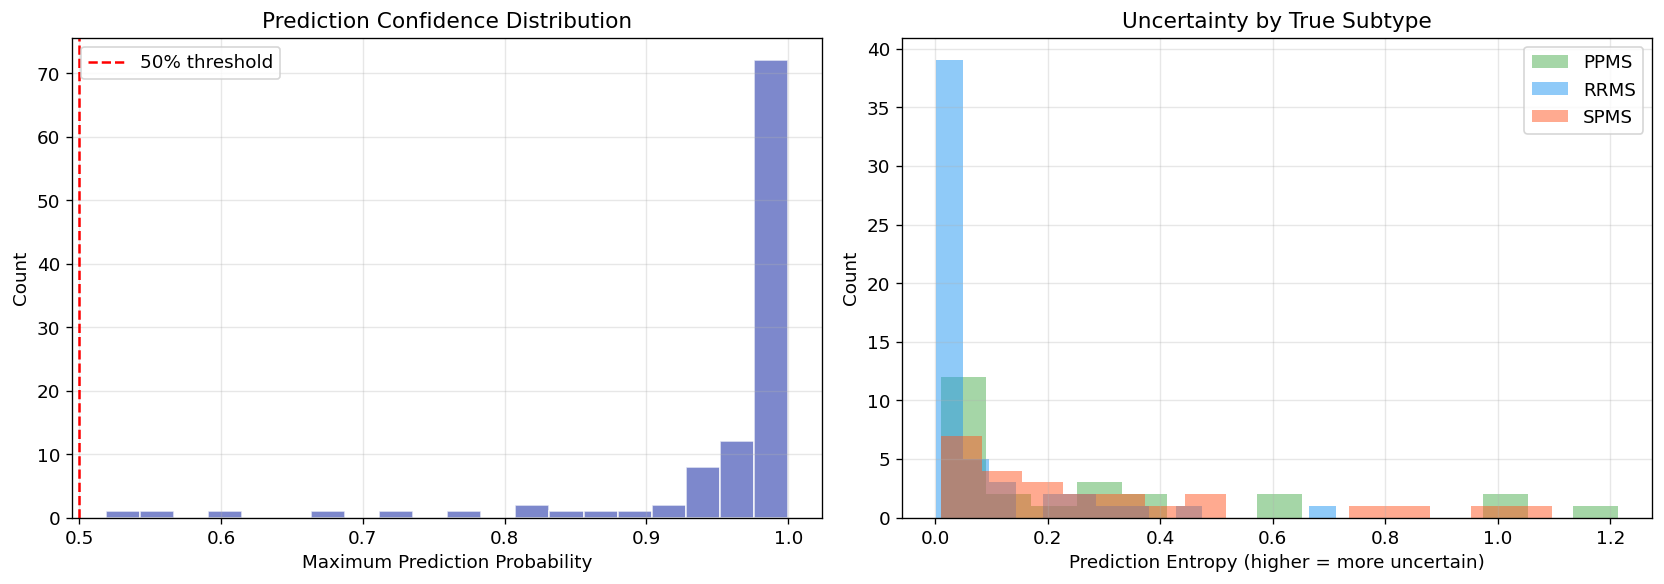

Top 5 Most Uncertain Patients:
 Index   True   Pred  MaxProb  Entropy
    50   PPMS   SPMS   0.5189   1.0069
     2   PPMS   PPMS   0.5441   0.9985
    34   PPMS   PPMS   0.6073   1.2142
    89   SPMS   SPMS   0.6737   1.0970
    54   SPMS   PPMS   0.7270   0.8529


In [11]:
# Find uncertain patients (max probability is low)
proba = model.predict_proba(X_test_ready)
max_proba = proba.max(axis=1)
entropy = -np.sum(proba * np.log2(proba + 1e-10), axis=1)

# Plot prediction confidence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(max_proba, bins=20, color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[0].axvline(0.5, color='red', linestyle='--', label='50% threshold')
axes[0].set_xlabel('Maximum Prediction Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution')
axes[0].legend()

# Entropy by subtype
for class_idx, name in enumerate(class_names):
    mask = y_test == class_idx
    if mask.sum() > 0:
        axes[1].hist(entropy[mask], bins=15, alpha=0.5, label=name, color=COLORS[name])
axes[1].set_xlabel('Prediction Entropy (higher = more uncertain)')
axes[1].set_ylabel('Count')
axes[1].set_title('Uncertainty by True Subtype')
axes[1].legend()

plt.tight_layout()
plt.show()

# Most uncertain patients
uncertain_idx = np.argsort(max_proba)[:5]
print("Top 5 Most Uncertain Patients:")
print(f"{'Index':>6} {'True':>6} {'Pred':>6} {'MaxProb':>8} {'Entropy':>8}")
for i in uncertain_idx:
    true_name = class_names[y_test[i]]
    pred_name = class_names[y_pred[i]]
    print(f"{i:6d} {true_name:>6} {pred_name:>6} {max_proba[i]:8.4f} {entropy[i]:8.4f}")

## 9. Counterfactual for the Most Uncertain Patient

The most uncertain patient is the most interesting case — a small change could flip the prediction.

In [12]:
# Generate counterfactual for the most uncertain patient
most_uncertain = uncertain_idx[0]
patient = X_test_ready.iloc[[most_uncertain]]
true_label = class_names[y_test[most_uncertain]]
pred_label = class_names[y_pred[most_uncertain]]
probs = proba[most_uncertain]

print(f"Most Uncertain Patient (index {most_uncertain}):")
print(f"  True: {true_label}, Predicted: {pred_label}")
print(f"  Probabilities: {dict(zip(class_names, probs.round(4)))}")
print(f"\nCurrent values:")
for col in feature_cols:
    print(f"  {col:30s} {patient[col].values[0]:.2f}")

# For multi-class: target the true label if misclassified, else second-most-likely class
if true_label != pred_label:
    target_cf_idx = int(list(class_names).index(true_label))
else:
    sorted_probs = sorted(enumerate(probs), key=lambda x: x[1], reverse=True)
    target_cf_idx = int(sorted_probs[1][0])  # Second most likely class

print(f"\nTarget counterfactual class: {class_names[target_cf_idx]} (index {target_cf_idx})")
print(f"Counterfactuals (what would change the prediction?):")
try:
    cf = dice_exp.generate_counterfactuals(
        patient,
        total_CFs=4,
        desired_class=target_cf_idx,
        features_to_vary=continuous_features,
        random_seed=RANDOM_STATE
    )
    cf.visualize_as_dataframe(show_only_changes=True)
except Exception as e:
    print(f"  Error: {e}")

Most Uncertain Patient (index 50):
  True: PPMS, Predicted: SPMS
  Probabilities: {'PPMS': np.float32(0.4804), 'RRMS': np.float32(0.0007), 'SPMS': np.float32(0.5189)}

Current values:
  age                            56.00
  sex_encoded                    1.00
  age_at_onset                   37.00
  edss                           5.00
  disease_duration               19.00
  relapse_count                  0.00
  treatment_status               1.00
  brain_volume                   1308712.60
  gm_volume                      523090.40
  wm_volume                      457434.90
  lesion_count                   61.00
  lesion_volume                  14702.60
  edss_progression_rate          0.74
  gm_ratio                       0.40
  wm_ratio                       0.35
  lesion_burden_ratio            0.01

Target counterfactual class: PPMS (index 0)
Counterfactuals (what would change the prediction?):



  0%|          | 0/1 [00:00<?, ?it/s]


100%|██████████| 1/1 [00:58<00:00, 58.75s/it]


100%|██████████| 1/1 [00:58<00:00, 58.75s/it]

Query instance (original outcome : 2)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,56.0,1.0,37.0,5.0,19.0,0.0,1.0,1308712.625,523090.40625,457434.90625,61.0,14702.599609,0.7358,0.3997,0.3495,0.011234,2



Diverse Counterfactual set (new outcome: 0)


,age,sex_encoded,age_at_onset,edss,disease_duration,relapse_count,treatment_status,brain_volume,gm_volume,wm_volume,lesion_count,lesion_volume,edss_progression_rate,gm_ratio,wm_ratio,lesion_burden_ratio,subtype
0,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.0
1,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.47613577,-,0.0
2,-,-,-,-,-,-,-,-,-,-,-,-,-,-,0.31857928,-,0.0
3,-,-,-,2.2,-,-,-,-,-,-,-,-,-,-,-,-,0.0


## 10. Clinical Summary

### Key Findings

1. **Counterfactuals identify actionable boundaries** — they show which clinical changes would reclassify a patient
2. **Feature change frequency** reveals which features are most critical for subtype differentiation
3. **Prediction uncertainty** identifies patients at subtype boundaries who may benefit from closer monitoring
4. **Diverse counterfactuals** provide multiple scenarios for clinical reasoning

### Complementarity with SHAP

| Analysis | SHAP | Counterfactuals |
|----------|------|----------------|
| Question | "Why this prediction?" | "What would change it?" |
| Perspective | Backward-looking | Forward-looking |
| Clinical use | Understanding diagnosis | Planning & monitoring |
| Output | Feature contributions | Concrete scenarios |

### Limitations

- Counterfactuals may suggest changes that are **not clinically feasible** (e.g., reducing disease duration)
- Features that are **immutable** (age, sex) should be excluded from variation
- Generated counterfactuals are **model-dependent** — different models may suggest different changes
- Clinical validation is necessary before using counterfactuals for patient advisement